In [33]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Set the working directorty
working_dir = r"C:/Users/valentin.stuhlfauth/OneDrive - univ-lyon2.fr/1_WSL/1_SGR visuals/git_repo_sgr_visuals"
os.chdir(working_dir)

import plot_functions
print(plot_functions.__file__)

# Set font
plt.rcParams['font.family'] = 'Arial'

c:\Users\valentin.stuhlfauth\OneDrive - univ-lyon2.fr\1_WSL\1_SGR visuals\git_repo_sgr_visuals\plot_functions.py


Put the: 
- Trade balance in '#fb8072'
- the values in the bar plot in: '#ffd558', '#b3de69', '#80b1d3', '#fdb462', '#bebada', '#8dd3c7','#ffffb3'... 

# Goods

In [34]:
df_imports = pd.read_csv(r'1_data_prep\indicator_trade\trade_good_imports.csv')
df_exports = pd.read_csv(r'1_data_prep\indicator_trade\trade_good_exports.csv')
df_gdp = pd.read_csv(r'1_data_prep\indicator_economy\gdp_cp.csv')

In [35]:
# filters
# ['ACP', 'AE', 'AFR', 'AME', 'AME_LAT', 'AR', 'ASEAN', 'ASI',
# 'ASI_OTH', 'ASI_W_IR', 'AU', 'BR', 'CA', 'CC9_23', 'CH', 'CIS',
#'CL', 'CN_X_HK', 'DAE', 'DZ', 'EFTA', 'EG', 'EU27_2020',
#'EUR_NEU27_2020', 'EXT_EU27_2020', 'HK', 'ID', 'IL', 'IN', 'IR',
#'JP', 'KR', 'KZ', 'LY', 'MA', 'MED_X_HR', 'MX', 'MY', 'NG', 'NO',
#'OCE_PLR', 'OPEC', 'RU', 'SA', 'SG', 'TH', 'TN', 'TR', 'TW', 'UA',
#'UK', 'US', 'USMCA', 'VN', 'WBC', 'ZA']
regions = ['ACP', 'AE', 'AFR', 'AME_LAT', 'WBC',
       'ASI_OTH', 'AU', 'BR', 'CA', 'CC9_23', 'CH', 'US'
        'CN_X_HK',  'EFTA',  'OCE_PLR','IN',  'JP',  'OPEC','RU']
countries = [ 'AE', 'AR', 'AU', 'BR', 'CA', 'CH', 'CN_X_HK',
       'CL', 'DZ', 'EG', 'HK', 'ID', 'IL', 'IN', 'IR',
       'JP', 'KR', 'KZ', 'LY', 'MA', 'MX', 'MY', 'NG', 'NO',
       'RU', 'SA', 'SG', 'TH', 'TN', 'TR', 'TW', 'UA',
       'UK', 'US', 'VN', 'ZA']

In [36]:
df_exports = df_exports[df_exports['partner'].isin(countries)]
df_imports = df_imports[df_imports['partner'].isin(countries)]

In [37]:
target_year = 2024
n_partners = 15

In [38]:
# Filter data for the target year
imports = df_imports[(df_imports['year'] == target_year)&(df_imports['geo'] == "EU27_2020")].copy()
exports = df_exports[(df_exports['year'] == target_year)&(df_exports['geo'] == "EU27_2020")].copy()

# Merge imports and exports
trade_summary = pd.merge(
    imports, 
    exports[['partner', 'value']], 
    on='partner', 
    how='outer', 
    suffixes=('_imports', '_exports')
).fillna(0)

# Calculate total trade and balance volume
trade_summary['total_trade'] = trade_summary['value_imports'] + trade_summary['value_exports']
trade_summary['balance_trade'] = trade_summary['value_exports'] - trade_summary['value_imports']

In [39]:
top_partners = trade_summary.nlargest(n_partners, 'total_trade')
top_partners.to_csv(r"trade_summary.csv")

top_partners_values = top_partners['partner'].values

### Graph export imports partners

#### All

In [40]:
top_partners.columns

Index(['Unnamed: 0', 'freq', 'stk_flow', 'indic_et', 'partner', 'sitc06',
       'geo', 'year', 'value_imports', 'value_exports', 'total_trade',
       'balance_trade'],
      dtype='object')

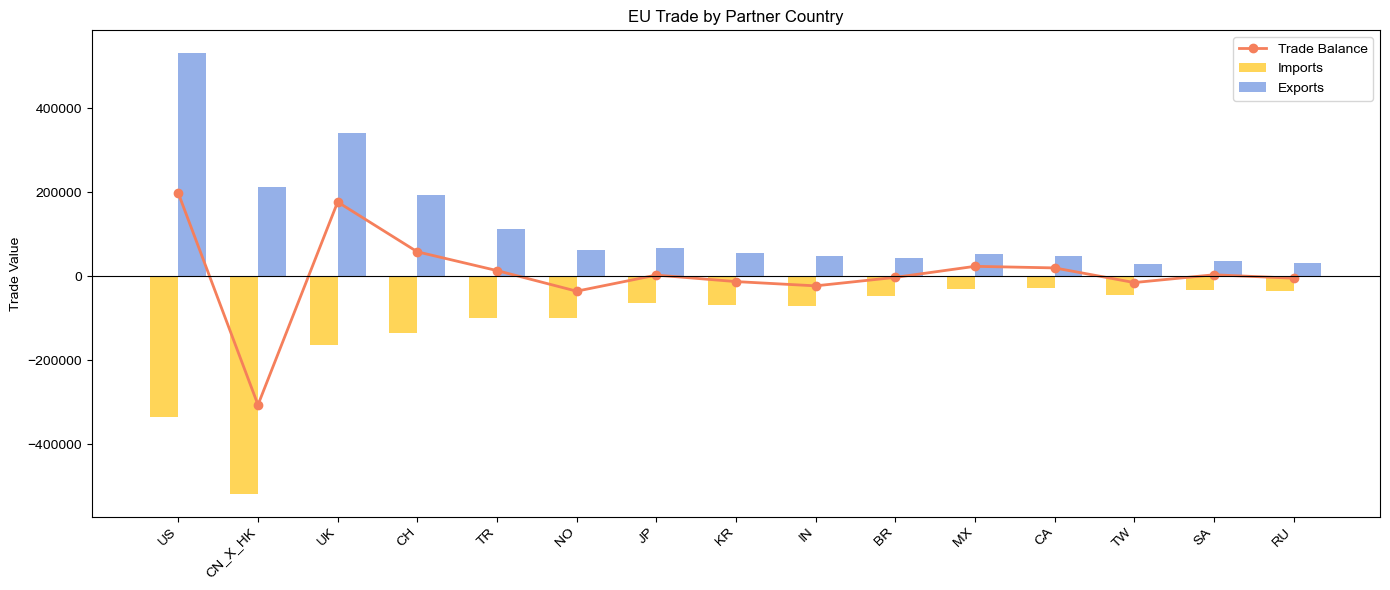

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by total trade or another metric for readability
top_partners_sorted = top_partners.sort_values('total_trade', ascending=False)

partners = top_partners_sorted['partner']
imports = -top_partners_sorted['value_imports']
exports = top_partners_sorted['value_exports']  # negative for visual
balance = top_partners_sorted['balance_trade']

x = np.arange(len(partners))
bar_width = 0.35

# Create plot
plt.figure(figsize=(14, 6))

# Imports bar
plt.bar(x - bar_width/2, imports, width=bar_width, label='Imports', color='#ffd558')

# Exports bar (plotted negative)
plt.bar(x + bar_width/2, exports, width=bar_width, label='Exports', color='#95b0e8')

# Trade balance as line
plt.plot(x, balance, color='#f57f5b', label='Trade Balance', marker='o', linewidth=2)


# Decorations
plt.xticks(x, partners, rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Trade Value')
plt.title('EU Trade by Partner Country')
plt.legend()
plt.tight_layout()
plt.show()


#### Per product types

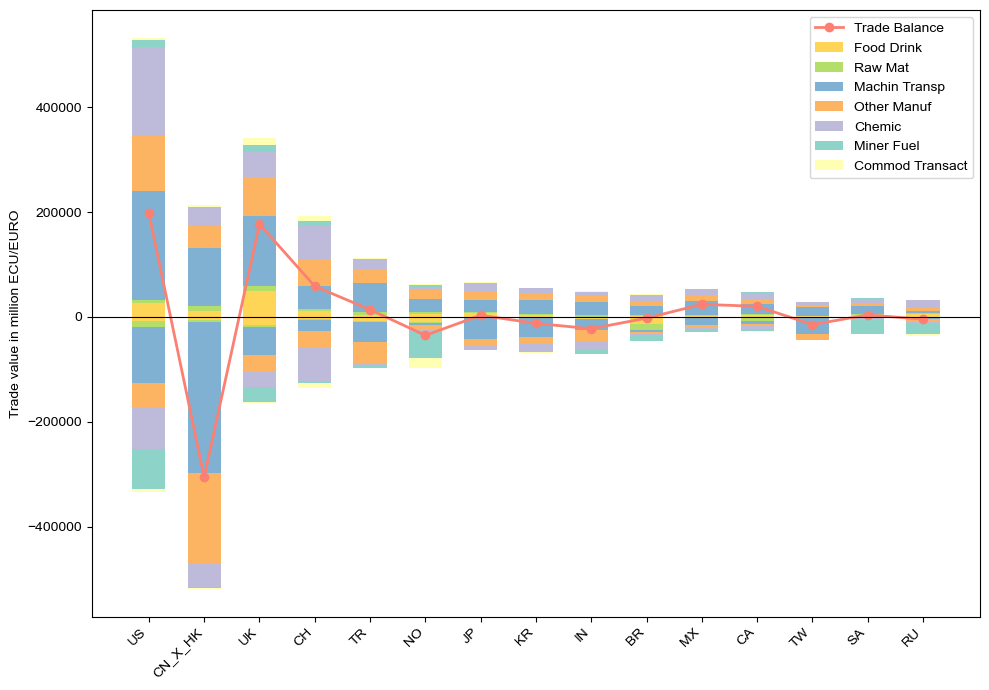

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
exports_files = [
    ('food_drink', r'1_data_prep\indicator_trade\trade_good_exports_food_drink.csv'),
    ('raw_mat', r'1_data_prep\indicator_trade\trade_good_exports_raw_mat.csv'),
    ('machin_transp', r'1_data_prep\indicator_trade\trade_good_exports_machin_transp.csv'),
    ('other_manuf', r'1_data_prep\indicator_trade\trade_good_exports_other_manuf.csv'),
    ('chemic', r'1_data_prep\indicator_trade\trade_good_exports_chemic.csv'),
    ('miner_fuel', r'1_data_prep\indicator_trade\trade_good_exports_miner_fuel.csv'),
    ('commod_transact', r'1_data_prep\indicator_trade\trade_good_exports_commod_transact.csv')
]

imports_files = [
    ('food_drink', r'1_data_prep\indicator_trade\trade_good_imports_food_drink.csv'),
    ('raw_mat', r'1_data_prep\indicator_trade\trade_good_imports_raw_mat.csv'),
    ('machin_transp', r'1_data_prep\indicator_trade\trade_good_imports_machin_transp.csv'),
    ('other_manuf', r'1_data_prep\indicator_trade\trade_good_imports_other_manuf.csv'),
    ('chemic', r'1_data_prep\indicator_trade\trade_good_imports_chemic.csv'),
    ('miner_fuel', r'1_data_prep\indicator_trade\trade_good_imports_miner_fuel.csv'),
    ('commod_transact', r'1_data_prep\indicator_trade\trade_good_imports_commod_transact.csv')
]



# Parameters
target_year = 2024
n_partners = 15
selected_countries = [
    'AE', 'AR', 'AU', 'BR', 'CA', 'CH', 'CN_X_HK', 'CL', 'DZ', 'EG', 'HK', 'ID', 'IL', 'IN', 'IR',
    'JP', 'KR', 'KZ', 'LY', 'MA', 'MX', 'MY', 'NG', 'NO', 'RU', 'SA', 'SG', 'TH', 'TN', 'TR', 'TW',
    'UA', 'UK', 'US', 'VN', 'ZA'
]
colors = ['#ffd558', '#b3de69', '#80b1d3', '#fdb462', '#bebada', '#8dd3c7','#ffffb3',]  # consistent colors for imports/exports
balance_color = '#fb8072'

# Helper to load and prepare trade data
def load_trade_data(file_list, year):
    dfs = []
    for category, path in file_list:
        df = pd.read_csv(path)
        df = df[(df['year'] == year)&(df['geo'] == "EU27_2020")]
        df = df.groupby('partner')['value'].sum().reset_index()
        df.rename(columns={'value': category}, inplace=True)
        dfs.append(df)
    return dfs

from functools import reduce

# Load and merge exports/imports
exports_dfs = load_trade_data(exports_files, target_year)
imports_dfs = load_trade_data(imports_files, target_year)

exports = reduce(lambda left, right: pd.merge(left, right, on='partner', how='outer'), exports_dfs).fillna(0)
imports = reduce(lambda left, right: pd.merge(left, right, on='partner', how='outer'), imports_dfs).fillna(0)

exports['total_exports'] = exports[[cat for cat, _ in exports_files]].sum(axis=1)
imports['total_imports'] = imports[[cat for cat, _ in imports_files]].sum(axis=1)

# Merge import/export data
trade = pd.merge(exports, imports, on='partner', suffixes=('_exp', '_imp')).fillna(0)
trade['balance'] = trade['total_exports'] - trade['total_imports']
trade['total_trade'] = trade['total_exports'] + trade['total_imports']

# Filter only selected countries
trade = trade[trade['partner'].isin(selected_countries)]

# Keep only top N partners by total trade
trade = trade.sort_values('total_trade', ascending=False).head(n_partners).reset_index(drop=True)

# Plotting
partners = trade['partner']
x = np.arange(len(partners))
bar_width = 0.6

fig, ax = plt.subplots(figsize=(10, 7))

# Plot stacked exports
bottom_exp = np.zeros(len(partners))
for i, (cat, _) in enumerate(exports_files):
    values = trade[f"{cat}_exp"]
    ax.bar(x, values, bottom=bottom_exp, width=bar_width, label=f'{cat.replace("_", " ").title()}', color=colors[i])
    bottom_exp += values

# Plot stacked imports (negative, same colors)
bottom_imp = np.zeros(len(partners))
for i, (cat, _) in enumerate(imports_files):
    values = -trade[f"{cat}_imp"]
    ax.bar(x, values, bottom=bottom_imp, width=bar_width, color=colors[i])
    bottom_imp += values

# Trade balance line
ax.plot(x, trade['balance'], color=balance_color, label='Trade Balance', marker='o', linewidth=2)

# Decorations
ax.set_xticks(x)
ax.set_xticklabels(partners, rotation=45, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Trade value in million ECU/EURO')
#ax.set_title(f'EU Trade with Top {n_partners} Partners (from Selected Countries) in {target_year}')
#ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0))
ax.legend()
plt.tight_layout()
plt.show()


In [43]:
trade

,partner,food_drink_exp,raw_mat_exp,machin_transp_exp,other_manuf_exp,chemic_exp,miner_fuel_exp,commod_transact_exp,total_exports,food_drink_imp,raw_mat_imp,machin_transp_imp,other_manuf_imp,chemic_imp,miner_fuel_imp,commod_transact_imp,total_imports,balance,total_trade
0,US,25757.3,7009.5,207809.5,104974.1,170095.2,12182.5,4960.4,532788.5,8187.4,10901.4,106140.2,48199.2,78391.2,76691.8,6496.5,335007.7,197780.8,867796.2
1,CN_X_HK,11225.1,10221.0,109456.7,42558.2,35579.5,700.1,3457.5,213198.1,6253.0,4109.3,287080.8,173955.8,44013.0,2044.4,1578.1,519034.4,-305836.3,732232.5
2,UK,49814.1,8468.1,133849.7,75089.1,46599.2,14930.7,12049.4,340800.3,15631.3,3787.6,53976.8,32209.7,28470.0,27689.0,2059.1,163823.5,176976.8,504623.8
3,CH,11178.6,3069.9,45174.9,51416.4,64285.7,7367.0,10821.3,193313.8,4744.8,1850.8,20365.6,31473.2,63523.6,3756.6,9182.1,134896.7,58417.1,328210.5
4,TR,4291.3,5559.0,54190.2,28065.1,16882.8,2210.0,962.4,112160.8,7296.4,2878.1,38708.4,38584.0,6290.7,4418.9,222.8,98399.3,13761.5,210560.1
5,NO,5612.1,3040.3,24950.2,16796.0,6788.6,4168.1,1484.7,62840.0,8836.8,2446.7,4148.5,9279.4,3529.1,50032.6,19836.4,98109.5,-35269.5,160949.5
6,JP,7605.2,1764.7,22283.8,15428.3,18213.0,111.0,1402.0,66808.0,504.7,765.2,40262.2,13861.0,8113.4,45.8,219.8,63772.1,3035.9,130580.1
7,KR,3643.3,1135.2,27806.6,12045.0,9879.7,498.9,689.5,55698.2,558.7,684.7,36442.9,13594.7,15488.2,1102.9,255.0,68127.1,-12428.9,123825.3
8,IN,700.9,3348.2,24774.5,11052.9,7920.8,439.5,467.2,48704.0,3522.1,1440.4,19316.8,23357.6,16488.2,7068.1,97.7,71290.9,-22586.9,119994.9
9,BR,1928.3,1041.7,18058.8,7853.6,12143.6,1197.5,1345.8,43569.3,13836.8,11382.2,2940.7,3640.9,1877.9,11945.0,360.7,45984.2,-2414.9,89553.5


In [44]:
trade.rename(columns={'value_y':'Final energy','value_x':'Population'}).to_excel(r'figure_9.xlsx')

## Balance accross time

In [45]:
df_exports = df_exports[df_exports['partner'].isin(countries)]
df_imports = df_imports[df_imports['partner'].isin(countries)]

# Merge imports and exports
trade_summary = pd.merge(
    df_imports, 
    df_exports[['partner', 'year', 'value']], 
    on=['partner','year'], 
    how='outer', 
    suffixes=('_imports', '_exports')
).fillna(0)

pd.merge(trade_summary, df_gdp[df_gdp['geo']=='EU27_2020'][['year','value']].rename(columns={'value':'gdp'}), on='year')

,Unnamed: 0,freq,stk_flow,indic_et,partner,sitc06,geo,year,value_imports,value_exports,gdp
0,453456,M,IMP,TRD_VAL,AE,TOTAL,EU27_2020,2002,1814.2,12214.4,8559614.0
1,453457,M,IMP,TRD_VAL,AE,TOTAL,EU27_2020,2003,2325.0,13576.8,8792709.3
2,453458,M,IMP,TRD_VAL,AE,TOTAL,EU27_2020,2004,3940.0,14934.3,9195744.5
3,453459,M,IMP,TRD_VAL,AE,TOTAL,EU27_2020,2005,8098.3,17519.8,9600083.4
4,453460,M,IMP,TRD_VAL,AE,TOTAL,EU27_2020,2006,4402.8,20136.3,10160799.0
...,...,...,...,...,...,...,...,...,...,...,...
823,474018,M,IMP,TRD_VAL,ZA,TOTAL,EU27_2020,2020,16486.9,17577.4,13579019.2
824,474019,M,IMP,TRD_VAL,ZA,TOTAL,EU27_2020,2021,22113.7,22010.8,14787713.6
825,474020,M,IMP,TRD_VAL,ZA,TOTAL,EU27_2020,2022,29224.3,26289.3,16136043.0
826,474021,M,IMP,TRD_VAL,ZA,TOTAL,EU27_2020,2023,23522.5,25937.7,17199527.6


In [46]:
df_exports = df_exports[df_exports['partner'].isin(countries)]
df_imports = df_imports[df_imports['partner'].isin(countries)]

# Merge imports and exports
trade_summary = pd.merge(
    df_imports, 
    df_exports[['partner', 'year', 'value']], 
    on=['partner','year'], 
    how='outer', 
    suffixes=('_imports', '_exports')
).fillna(0)

trade_summary = pd.merge(trade_summary, df_gdp[df_gdp['geo']=='EU27_2020'][['year','value']].rename(columns={'value':'gdp'}), on='year')

trade_summary = trade_summary.dropna(subset=['value_imports', 'value_exports', 'gdp'])

trade_summary['total_trade'] = (trade_summary['value_imports'] + trade_summary['value_exports'])/trade_summary['gdp']*100
trade_summary['balance_trade'] = (trade_summary['value_exports'] - trade_summary['value_imports'])/trade_summary['gdp']*100

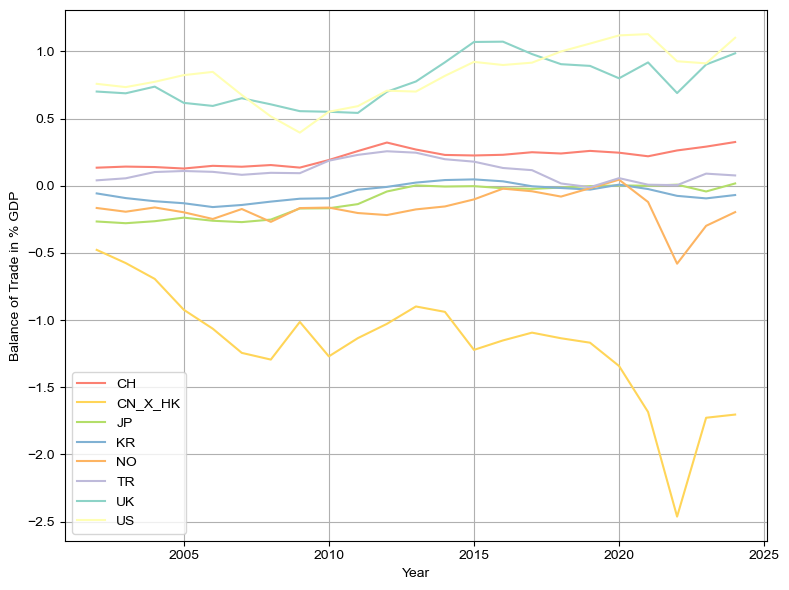

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'year' is sorted properly
trade_summary = trade_summary.sort_values(by='year')

# Filter for top partners
country_partners = ['US', 'CN_X_HK', 'UK', 'CH', 'TR', 'NO', 'JP', 'KR']
trade_summary_top = trade_summary[trade_summary['partner'].isin(country_partners)]

# Define colors for each partner
colors = ['#fb8072', '#ffd558', '#b3de69', '#80b1d3', '#fdb462', '#bebada', '#8dd3c7', '#ffffb3']

# Create the plot
plt.figure(figsize=(8, 6))

# Loop over each partner and plot with specified color
for i, (partner, group) in enumerate(trade_summary_top.groupby('partner')):
    plt.plot(group['year'], group['balance_trade'], label=partner, color=colors[i])

# Customize plot
plt.xlabel('Year')
plt.ylabel('Balance of Trade in % GDP')
#plt.title('Trade Balance Over Time by Partner')
#plt.legend(title='Partner', bbox_to_anchor=(1.05, 1), loc='upper left')  # legend outside
plt.legend()
plt.tight_layout()
plt.grid(True)

# Show plot
plt.show()


In [48]:
trade_summary_top

,Unnamed: 0,freq,stk_flow,indic_et,partner,sitc06,geo,year,value_imports,value_exports,gdp,total_trade,balance_trade
667,470976,M,IMP,TRD_VAL,TR,TOTAL,EU27_2020,2002,21011.7,24446.4,8559614.0,0.531077,0.040127
529,467952,M,IMP,TRD_VAL,NO,TOTAL,EU27_2020,2002,39483.8,25301.7,8559614.0,0.756874,-0.165686
115,458400,M,IMP,TRD_VAL,CH,TOTAL,EU27_2020,2002,56500.5,67997.9,8559614.0,1.454486,0.134321
368,464880,M,IMP,TRD_VAL,KR,TOTAL,EU27_2020,2002,20203.5,15307.0,8559614.0,0.414861,-0.057205
345,464496,M,IMP,TRD_VAL,JP,TOTAL,EU27_2020,2002,60520.1,37738.7,8559614.0,1.147935,-0.266150
...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,464518,M,IMP,TRD_VAL,JP,TOTAL,EU27_2020,2024,63772.0,66808.0,17956656.6,0.727196,0.016907
390,464902,M,IMP,TRD_VAL,KR,TOTAL,EU27_2020,2024,68127.0,55698.2,17956656.6,0.689578,-0.069216
689,470998,M,IMP,TRD_VAL,TR,TOTAL,EU27_2020,2024,98399.9,112160.9,17956656.6,1.172606,0.076635
781,472510,M,IMP,TRD_VAL,US,TOTAL,EU27_2020,2024,335007.8,532789.0,17956656.6,4.832730,1.101437


In [49]:
trade_summary_top.columns

Index(['Unnamed: 0', 'freq', 'stk_flow', 'indic_et', 'partner', 'sitc06',
       'geo', 'year', 'value_imports', 'value_exports', 'gdp', 'total_trade',
       'balance_trade'],
      dtype='object')

In [50]:
trade_summary_top[['geo', 'year', 'value_imports', 'value_exports', 'gdp', 'total_trade','balance_trade']].rename(columns={'value_y':'Final energy','value_x':'Population'}).to_excel(r'figure_10.xlsx')

## Import export by product

### EU level

In [51]:
import pandas as pd
import os

# Folder path
folder = r'1_data_prep\indicator_trade'

# Define sectors manually from your file naming
sectors = [
    'commod_transact', 'machin_transp', 'other_manuf', 'chemic', 'miner_fuel', 'raw_mat',
    'food_drink', 'food_animal', 'bev_tobac', 'crude_mat', 'petrol', 'oil',
    'manuf_good', 'manuf_good_mat', 'miscellaneous'
]

# Load all export/import dataframes into a dictionary
exports = {}
imports = {}

for sector in sectors:
    exp_path = os.path.join(folder, f'trade_good_exports_{sector}.csv')
    imp_path = os.path.join(folder, f'trade_good_imports_{sector}.csv')
    exports[sector] = pd.read_csv(exp_path)
    imports[sector] = pd.read_csv(imp_path)


# Filter GDP to current prices and needed years
gdp_filtered = df_gdp[
#    (df_gdp['unit'] == 'CP_MEUR') &
    (df_gdp['na_item'] == 'B1GQ') &
    (df_gdp['year'].isin([2014, 2024]))
].copy()
gdp_filtered = gdp_filtered[['geo', 'year', 'value']].rename(columns={'value': 'gdp'})

# Build trade indicators
results = []

for sector in sectors:
    for year in [2014, 2024]:
        # Group by geo to get national totals
        exp = exports[sector][exports[sector]['year'] == year].groupby('geo')['value'].sum()
        imp = imports[sector][imports[sector]['year'] == year].groupby('geo')['value'].sum()
        
        # GDP for the same geos/year
        gdp = gdp_filtered[gdp_filtered['year'] == year].set_index('geo')['gdp']
        
        # Align indexes
        common_geos = exp.index.intersection(imp.index).intersection(gdp.index)
        exp = exp[common_geos]
        imp = imp[common_geos]
        gdp = gdp[common_geos]
        
        # Compute metrics
        exp_pct = (exp / gdp * 100)
        imp_pct = (imp / gdp * 100)
        #trade_pct = ((exp + imp) / gdp * 100)
        balance_pct = ((exp - imp) / gdp * 100)
        
        # Average across countries
        results.append({
            'Sector': sector,
            'Year': year,
            'Exports % GDP': exp_pct.mean(),
            'Imports % GDP': imp_pct.mean(),
            #'Total Trade % GDP': trade_pct.mean(),
            'Trade Balance % GDP': balance_pct.mean()
        })

# Final tidy DataFrame
df_result = pd.DataFrame(results)

# Pivot to make visual-ready
table = df_result.pivot(index='Sector', columns='Year')
table.columns = [f"{metric} {year}" for metric, year in table.columns]
table = table.reset_index()
table = table.round(2)

# Show preview
print(table.head())


            Sector  Exports % GDP 2014  Exports % GDP 2024  \
0        bev_tobac                1.21                1.24   
1           chemic               13.42               16.15   
2  commod_transact                1.43                1.23   
3        crude_mat                2.05                1.92   
4      food_animal                5.24                5.77   

   Imports % GDP 2014  Imports % GDP 2024  Trade Balance % GDP 2014  \
0                0.52                0.53                      0.69   
1                9.37               11.08                      4.05   
2                1.85                1.10                     -0.42   
3                2.71                2.43                     -0.66   
4                4.71                5.30                      0.53   

   Trade Balance % GDP 2024  
0                      0.71  
1                      5.07  
2                      0.12  
3                     -0.50  
4                      0.47  


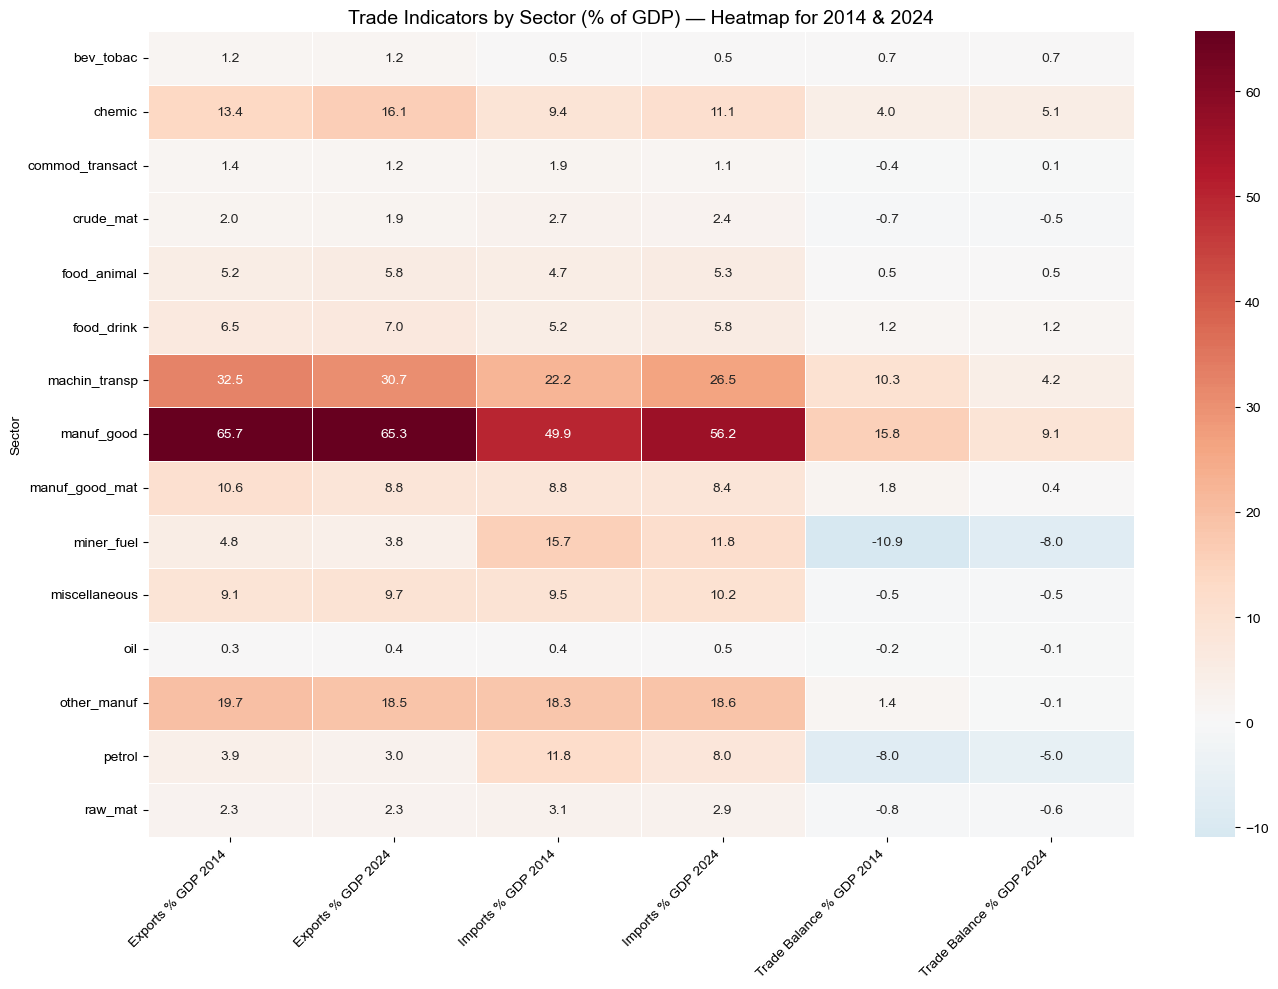

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# You already have this table from the previous step
# `table` has Sector as index and columns like "Exports % GDP 2014", etc.

# Set 'Sector' as index again if it was reset
table_heatmap = table.set_index('Sector')

# Create the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    table_heatmap,
    cmap='RdBu_r',
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    center=0  # Especially useful for Trade Balance values
)

plt.title('Trade Indicators by Sector (% of GDP) — Heatmap for 2014 & 2024', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [53]:
table_heatmap

,Exports % GDP 2014,Exports % GDP 2024,Imports % GDP 2014,Imports % GDP 2024,Trade Balance % GDP 2014,Trade Balance % GDP 2024
Sector,,,,,,
bev_tobac,1.21,1.24,0.52,0.53,0.69,0.71
chemic,13.42,16.15,9.37,11.08,4.05,5.07
commod_transact,1.43,1.23,1.85,1.10,-0.42,0.12
crude_mat,2.05,1.92,2.71,2.43,-0.66,-0.50
food_animal,5.24,5.77,4.71,5.30,0.53,0.47
food_drink,6.45,7.01,5.23,5.83,1.22,1.18
machin_transp,32.53,30.67,22.21,26.53,10.32,4.15
manuf_good,65.68,65.29,49.92,56.16,15.76,9.13
manuf_good_mat,10.63,8.75,8.80,8.37,1.83,0.38


In [54]:
table_heatmap.reset_index().rename(columns={'value_y':'Final energy','value_x':'Population'}).to_excel(r'figure_11.xlsx')

### EU countries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
trade_good_imports_all_countries = pd.read_csv(r'1_data_prep\indicator_trade\trade_good_imports_all_countries.csv')
trade_serv_export_all_countries = pd.read_csv(r'1_data_prep\indicator_trade\trade_good_exports_all_countries.csv')
df_gdp = pd.read_csv(r'1_data_prep\indicator_economy\gdp_cp.csv')

# Filter data for target year
imports_2024 = trade_good_imports_all_countries[trade_good_imports_all_countries['year'] == target_year]
exports_2024 = trade_serv_export_all_countries[trade_serv_export_all_countries['year'] == target_year]
gdp_2024 = df_gdp[df_gdp['year'] == target_year]

# Filter for only top partners (maintaining order)
imports_2024_filtered = imports_2024[imports_2024['partner'].isin(['US', 'CN', 'GB', 'CH', 'TR', 'NO', 'JP', 'KR', 'IN', 'BR', 'MX', 'CA', 'TW', 'SA', 'RU'])]
exports_2024_filtered = exports_2024[exports_2024['partner'].isin(['US', 'CN', 'GB', 'CH', 'TR', 'NO', 'JP', 'KR', 'IN', 'BR', 'MX', 'CA', 'TW', 'SA', 'RU'])]

# Merge imports and exports data
trade_data = pd.merge(
    exports_2024_filtered.rename(columns={'reporter':'geo'})[['geo', 'partner', 'value']], 
    imports_2024_filtered.rename(columns={'reporter':'geo'})[['geo', 'partner', 'value']], 
    on=['geo', 'partner'], 
    how='outer',
    suffixes=('_export', '_import')
)

In [56]:
# Fill NaN values with 0 (countries with no trade data)
trade_data['value_export'] = trade_data['value_export'].fillna(0)
trade_data['value_import'] = trade_data['value_import'].fillna(0)

# Calculate trade balance
trade_data['trade_balance'] = (trade_data['value_export'] - trade_data['value_import'])/1000000

# Merge with GDP data
trade_data_with_gdp = pd.merge(
    trade_data,
    gdp_2024[['geo', 'value']].rename(columns={'value': 'gdp'}),
    on='geo',
    how='left'
)

# Calculate trade balance per unit of GDP
trade_data_with_gdp['trade_balance_per_gdp'] = (
    trade_data_with_gdp['trade_balance'] / trade_data_with_gdp['gdp'] * 100
)

# Create pivot table for heatmap
heatmap_data = trade_data_with_gdp.pivot(
    index='geo', 
    columns='partner', 
    values='trade_balance_per_gdp'
)

# Reorder columns according to top_partners_values order
heatmap_data = heatmap_data.reindex(columns=['US', 'CN', 'GB', 'CH', 'TR', 'NO', 'JP', 'KR', 'IN', 'BR', 'MX', 'CA', 'TW', 'SA', 'RU'])

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
trade_good_imports_all_countries = pd.read_csv(r'1_data_prep\indicator_trade\trade_good_imports_all_countries.csv')
trade_serv_export_all_countries = pd.read_csv(r'1_data_prep\indicator_trade\trade_good_exports_all_countries.csv')
df_gdp = pd.read_csv(r'1_data_prep\indicator_economy\gdp_cp.csv')

# Fill missing values
gdp_2022 = df_gdp[df_gdp['year'] == target_year-2]
gdp_2023 = df_gdp[df_gdp['year'] == target_year-1]
gdp_2024 = df_gdp[df_gdp['year'] == target_year]

# Merge the 2024 dataset with the 2023 dataset on 'geo'
gdp_2024_filled = gdp_2024.merge(gdp_2023, on='geo', how='left', suffixes=('', '_2023'))
gdp_2024_filled = gdp_2024_filled.merge(gdp_2022, on='geo', how='left', suffixes=('', '_2022'))

# Fill the missing values in the 'value' column of 2024 with those from 2023
gdp_2024_filled['value'] = gdp_2024_filled['value'].fillna(gdp_2024_filled['value_2023'])
# Fill the missing values in the 'value' column of 2024 with those from 2022
gdp_2024_filled['value'] = gdp_2024_filled['value'].fillna(gdp_2024_filled['value_2022'])

# Drop the extra column used for filling
gdp_2024_filled = gdp_2024_filled.drop(columns=['value_2023'])
gdp_2024_filled = gdp_2024_filled.drop(columns=['value_2022'])

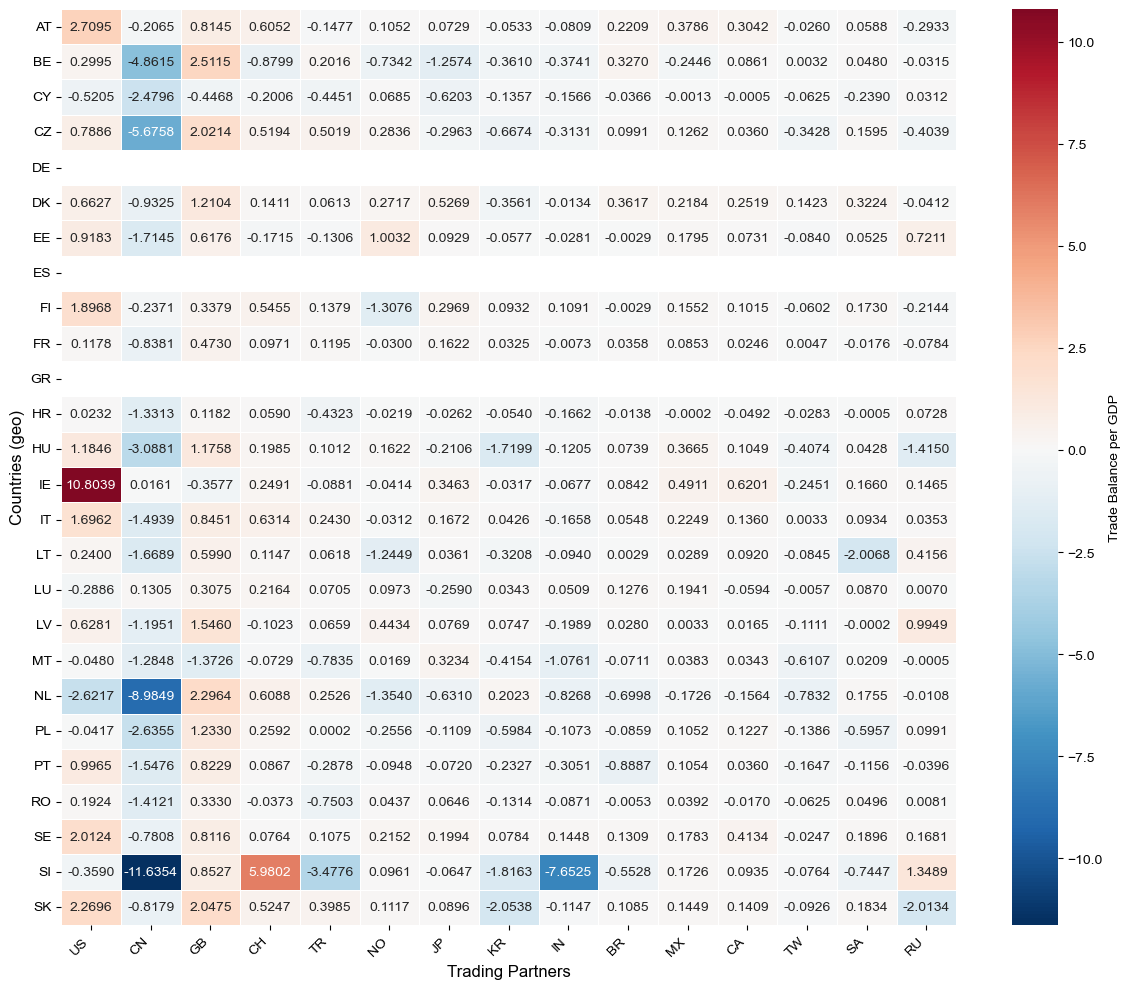

Summary Statistics:
Data shape: (26, 15)
Number of countries: 26
Number of partners: 15
Range of values: -11.6354 to 10.8039

Countries with missing GDP data: ['DE' 'ES' 'GR']


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
trade_good_imports_all_countries = pd.read_csv(r'1_data_prep\indicator_trade\trade_good_imports_all_countries.csv')
trade_serv_export_all_countries = pd.read_csv(r'1_data_prep\indicator_trade\trade_good_exports_all_countries.csv')
df_gdp = pd.read_csv(r'1_data_prep\indicator_economy\gdp_cp.csv')

# Fill missing values
gdp_2022 = df_gdp[df_gdp['year'] == target_year-2]
gdp_2023 = df_gdp[df_gdp['year'] == target_year-1]
gdp_2024 = df_gdp[df_gdp['year'] == target_year]

# Merge the 2024 dataset with the 2023 dataset on 'geo'
gdp_2024_filled = gdp_2024.merge(gdp_2023, on='geo', how='left', suffixes=('', '_2023'))
gdp_2024_filled = gdp_2024_filled.merge(gdp_2022, on='geo', how='left', suffixes=('', '_2022'))

# Fill the missing values in the 'value' column of 2024 with those from 2023
gdp_2024_filled['value'] = gdp_2024_filled['value'].fillna(gdp_2024_filled['value_2023'])
# Fill the missing values in the 'value' column of 2024 with those from 2022
gdp_2024_filled['value'] = gdp_2024_filled['value'].fillna(gdp_2024_filled['value_2022'])

# Drop the extra column used for filling
gdp_2024_filled = gdp_2024_filled.drop(columns=['value_2023'])
gdp_2024_filled = gdp_2024_filled.drop(columns=['value_2022'])


# Filter data for target year
imports_2024 = trade_good_imports_all_countries[trade_good_imports_all_countries['year'] == target_year]
exports_2024 = trade_serv_export_all_countries[trade_serv_export_all_countries['year'] == target_year]

# Filter for only top partners (maintaining order)
imports_2024_filtered = imports_2024[imports_2024['partner'].isin(['US', 'CN', 'GB', 'CH', 'TR', 'NO', 'JP', 'KR', 'IN', 'BR', 'MX', 'CA', 'TW', 'SA', 'RU'])]
exports_2024_filtered = exports_2024[exports_2024['partner'].isin(['US', 'CN', 'GB', 'CH', 'TR', 'NO', 'JP', 'KR', 'IN', 'BR', 'MX', 'CA', 'TW', 'SA', 'RU'])]

# Merge imports and exports data
trade_data = pd.merge(
    exports_2024_filtered.rename(columns={'reporter':'geo'})[['geo', 'partner', 'value']], 
    imports_2024_filtered.rename(columns={'reporter':'geo'})[['geo', 'partner', 'value']], 
    on=['geo', 'partner'], 
    how='outer',
    suffixes=('_export', '_import')
)

# Fill NaN values with 0 (countries with no trade data)
trade_data['value_export'] = trade_data['value_export'].fillna(0)
trade_data['value_import'] = trade_data['value_import'].fillna(0)

# Calculate trade balance
trade_data['trade_balance'] = (trade_data['value_export'] - trade_data['value_import'])/1000000

# Merge with GDP data
trade_data_with_gdp = pd.merge(
    trade_data,
    gdp_2024_filled[['geo', 'value']].rename(columns={'value': 'gdp'}),
    on='geo',
    how='left'
)

# Calculate trade balance per unit of GDP
trade_data_with_gdp['trade_balance_per_gdp'] = (
    trade_data_with_gdp['trade_balance'] / trade_data_with_gdp['gdp'] * 100
)

# Create pivot table for heatmap
heatmap_data = trade_data_with_gdp.pivot(
    index='geo', 
    columns='partner', 
    values='trade_balance_per_gdp'
)

# Reorder columns according to top_partners_values order
heatmap_data = heatmap_data.reindex(columns=['US', 'CN', 'GB', 'CH', 'TR', 'NO', 'JP', 'KR', 'IN', 'BR', 'MX', 'CA', 'TW', 'SA', 'RU'])

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.4f',
    cmap='RdBu_r',  # Red-Blue colormap (red for negative, blue for positive)
    center=0,
    cbar_kws={'label': 'Trade Balance per GDP'},
    linewidths=0.5
)

#plt.title(f'Trade Balance per Unit of GDP - {target_year}', fontsize=16, pad=20)
plt.xlabel('Trading Partners', fontsize=12)
plt.ylabel('Countries (geo)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Optional: Display summary statistics
print("Summary Statistics:")
print(f"Data shape: {heatmap_data.shape}")
print(f"Number of countries: {len(heatmap_data.index)}")
print(f"Number of partners: {len(heatmap_data.columns)}")
print(f"Range of values: {heatmap_data.min().min():.4f} to {heatmap_data.max().max():.4f}")

# Optional: Show countries with missing GDP data
missing_gdp = trade_data_with_gdp[trade_data_with_gdp['gdp'].isna()]['geo'].unique()
if len(missing_gdp) > 0:
    print(f"\nCountries with missing GDP data: {missing_gdp}")

In [59]:
heatmap_data

partner,US,CN,GB,CH,TR,NO,JP,KR,IN,BR,MX,CA,TW,SA,RU
geo,,,,,,,,,,,,,,,
AT,2.709518,-0.206481,0.814486,0.605174,-0.147662,0.105170,0.072881,-0.053317,-0.080915,0.220898,0.378649,0.304193,-0.026021,0.058775,-0.293276
BE,0.299480,-4.861462,2.511537,-0.879862,0.201626,-0.734245,-1.257404,-0.361002,-0.374055,0.327043,-0.244645,0.086059,0.003216,0.048000,-0.031482
CY,-0.520456,-2.479612,-0.446809,-0.200576,-0.445104,0.068542,-0.620345,-0.135739,-0.156642,-0.036587,-0.001317,-0.000512,-0.062522,-0.239004,0.031212
CZ,0.788598,-5.675813,2.021401,0.519411,0.501875,0.283641,-0.296272,-0.667431,-0.313111,0.099068,0.126187,0.036016,-0.342810,0.159511,-0.403929
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DK,0.662694,-0.932482,1.210388,0.141075,0.061311,0.271664,0.526878,-0.356089,-0.013357,0.361727,0.218434,0.251920,0.142269,0.322391,-0.041180
EE,0.918340,-1.714519,0.617644,-0.171524,-0.130647,1.003174,0.092935,-0.057672,-0.028133,-0.002857,0.179522,0.073055,-0.084045,0.052463,0.721098
ES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FI,1.896758,-0.237106,0.337904,0.545540,0.137915,-1.307632,0.296879,0.093220,0.109101,-0.002867,0.155220,0.101482,-0.060245,0.172960,-0.214386


In [61]:
heatmap_data.reset_index().rename(columns={'value_y':'Final energy','value_x':'Population'}).to_excel(r'figure_12.xlsx')

# Goods vs services

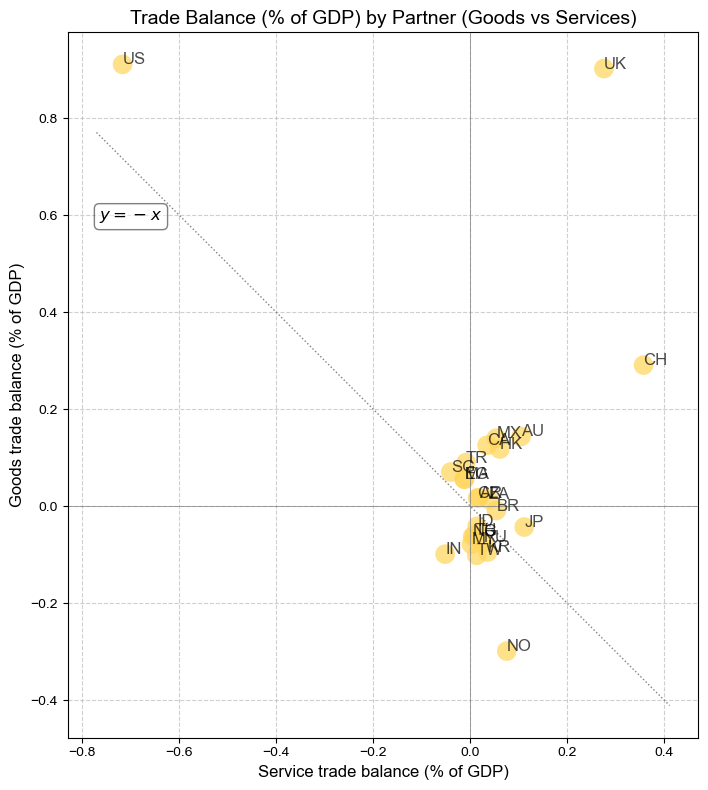

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df_imports_goods = pd.read_csv(r'1_data_prep\indicator_trade\trade_good_imports.csv')
df_exports_goods = pd.read_csv(r'1_data_prep\indicator_trade\trade_good_exports.csv')
df_imports_serv = pd.read_csv(r'1_data_prep\indicator_trade\trade_serv_import.csv')
df_exports_serv = pd.read_csv(r'1_data_prep\indicator_trade\trade_serv_export.csv')
df_gdp = pd.read_csv(r'1_data_prep\indicator_economy\gdp_cp.csv')

# Years of interest
years = 2023

# Filter GDP data
df_gdp = df_gdp[df_gdp['year'] == years]
df_gdp = df_gdp[df_gdp['na_item'] == 'B1GQ']  # Ensure it's GDP
df_gdp = df_gdp[['geo', 'year', 'value']].rename(columns={'value': 'gdp'})

# Function to prepare trade balance
def get_trade_balance(imports_df, exports_df, trade_type):
    df = pd.merge(exports_df, imports_df, on=['partner', 'geo', 'year'], suffixes=('_exp', '_imp'))
    df['balance'] = df['value_exp'] - df['value_imp']
    df = df[['partner', 'geo', 'year', 'balance']]
    df = df[df['year'] == years]
    return df.rename(columns={'balance': f'balance_{trade_type}'})

# Compute trade balances
goods = get_trade_balance(df_imports_goods, df_exports_goods, 'goods')
servs = get_trade_balance(df_imports_serv, df_exports_serv, 'services')

# Merge goods and services
trade = pd.merge(goods, servs, on=['partner', 'geo', 'year'])

# Merge GDP
trade = pd.merge(trade, df_gdp, on=['geo', 'year'])

# Compute balance as % of GDP
trade['goods_pct'] = 100 * trade['balance_goods'] / trade['gdp']
trade['services_pct'] = 100 * trade['balance_services'] / trade['gdp']

# Filters
countries = ['AE', 'AR', 'AU', 'BR', 'CA', 'CH', 'CN_X_HK',
             'CL', 'DZ', 'EG', 'HK', 'ID', 'IL', 'IN', 'IR',
             'JP', 'KR', 'KZ', 'LY', 'MA', 'MX', 'MY', 'NG', 'NO',
             'RU', 'SA', 'SG', 'TH', 'TN', 'TR', 'TW', 'UA',
             'UK', 'US', 'VN', 'ZA']
trade = trade[trade['partner'].isin(countries)]

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))
colors = {years: '#ffd558'}
df_year = trade[trade['year'] == years]

# Scatter plot
ax.scatter(
    df_year['services_pct'],
    df_year['goods_pct'],
    label=str(years),
    color=colors[years],
    s=200,  # Increase the size of the dots
    alpha=0.7,
    edgecolor='none'  # Remove contours
)

# Add country labels
for _, row in df_year.iterrows():
    ax.text(
        row['services_pct'],
        row['goods_pct'],
        row['partner'],
        fontsize=12,  # Increase the font size of the country labels
        alpha=0.7
    )

# Add y = -x line with consistent dotted style
x_range = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)
ax.plot(x_range, -x_range, linestyle=':', color='grey', linewidth=1)

# Add equation text
ax.text(0.05, 0.75, '$y = -x$', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Add grid
ax.grid(True, linestyle='--', alpha=0.6)

# Add horizontal and vertical lines at zero
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)

# Set equal aspect ratio
ax.set_aspect('equal', adjustable='box')

# Set labels and title
ax.set_xlabel("Service trade balance (% of GDP)", fontsize=12)
ax.set_ylabel("Goods trade balance (% of GDP)", fontsize=12)
ax.set_title("Trade Balance (% of GDP) by Partner (Goods vs Services)", fontsize=14)

plt.tight_layout()
plt.show()


In [29]:
trade.columns

Index(['partner', 'geo', 'year', 'balance_goods', 'balance_services', 'gdp',
       'goods_pct', 'services_pct'],
      dtype='object')

In [67]:
trade

,partner,geo,year,balance_goods,balance_services,gdp,goods_pct,services_pct
2,AR,EU27_2020,2023,2997.4,3039.0,17199527.6,0.017427,0.017669
5,AU,EU27_2020,2023,24741.1,18009.1,17199527.6,0.143848,0.104707
6,BR,EU27_2020,2023,-1511.6,9255.1,17199527.6,-0.008789,0.053810
7,CA,EU27_2020,2023,21624.8,5938.0,17199527.6,0.125729,0.034524
8,CH,EU27_2020,2023,50053.1,61418.0,17199527.6,0.291014,0.357091
9,CL,EU27_2020,2023,2945.2,2570.1,17199527.6,0.017124,0.014943
10,EG,EU27_2020,2023,9627.8,-2185.8,17199527.6,0.055977,-0.012708
13,HK,EU27_2020,2023,20305.2,10453.0,17199527.6,0.118057,0.060775
14,ID,EU27_2020,2023,-7097.2,2408.7,17199527.6,-0.041264,0.014004
15,IN,EU27_2020,2023,-16976.3,-8928.2,17199527.6,-0.098702,-0.051910


In [68]:
trade.reset_index().rename(columns={'value_y':'Final energy','value_x':'Population'}).to_excel(r'figure_14.xlsx')

# Dependency of countries to export

In [128]:
df_imports = pd.read_csv(r'1_data_prep\indicator_trade\trade_good_imports_all_countries.csv')
df_exports = pd.read_csv(r'1_data_prep\indicator_trade\trade_good_exports_all_countries.csv')
df_gdp = pd.read_csv(r'1_data_prep\indicator_economy\gdp_cp.csv')

In [129]:
eu27_countries = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 
                    'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 
                    'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']

In [130]:
year_ref = 2020

In [131]:
df = pd.merge(df_exports[['reporter','partner', 'year', 'value']], df_imports[['reporter', 'partner', 'year', 'value']], on=['reporter', 'partner', 'year'], suffixes=('_exports', '_imports'),)
df = pd.merge(df, df_gdp[['geo', 'year', 'value']], left_on=['reporter', 'year'], right_on=['geo', 'year'])

In [132]:
df = df[~df['partner'].isin(eu27_countries)]

In [133]:
df[df['reporter']=='DE']

,reporter,partner,year,value_exports,value_imports,geo,value
5598,DE,AD,2002,36663281.0,3102696.0,DE,1995960.2
5599,DE,AD,2004,33100409.0,3120876.0,DE,2141167.0
5600,DE,AD,2009,29000432.0,407591.0,DE,2323229.8
5601,DE,AD,2014,38954316.0,644608.0,DE,2782596.9
5602,DE,AD,2019,43817129.0,1027144.0,DE,3202754.4
...,...,...,...,...,...,...,...
7093,DE,ZW,2004,44265999.0,85088119.0,DE,2141167.0
7094,DE,ZW,2009,18613828.0,20575003.0,DE,2323229.8
7095,DE,ZW,2014,31253141.0,44798247.0,DE,2782596.9
7096,DE,ZW,2019,32743838.0,20159533.0,DE,3202754.4


In [134]:
df['balance'] = (df['value_exports'] - df['value_imports']) / df['value']*100/1000000
df['value_exports'] = (df['value_exports'] ) / df['value']*100/1000000

In [135]:
df[[ 'year', 'value_exports', 'value_imports', 'geo', 'balance']].groupby(['geo', 'year'])

In [136]:
df = df[[ 'year', 'value_exports', 'value_imports', 'geo', 'balance']].groupby(['geo', 'year']).sum().reset_index()

In [137]:
df[df['geo']=='NL']

,geo,year,value_exports,value_imports,balance
108,NL,2002,73.503965,3.550103e+11,-4.063761
109,NL,2004,78.195630,3.940936e+11,-4.170111
110,NL,2009,83.136182,4.988297e+11,-5.772014
111,NL,2014,112.196651,7.111065e+11,-6.046020
112,NL,2019,121.502862,9.074438e+11,-7.536896
113,NL,2024,117.156358,1.188741e+12,-6.973947


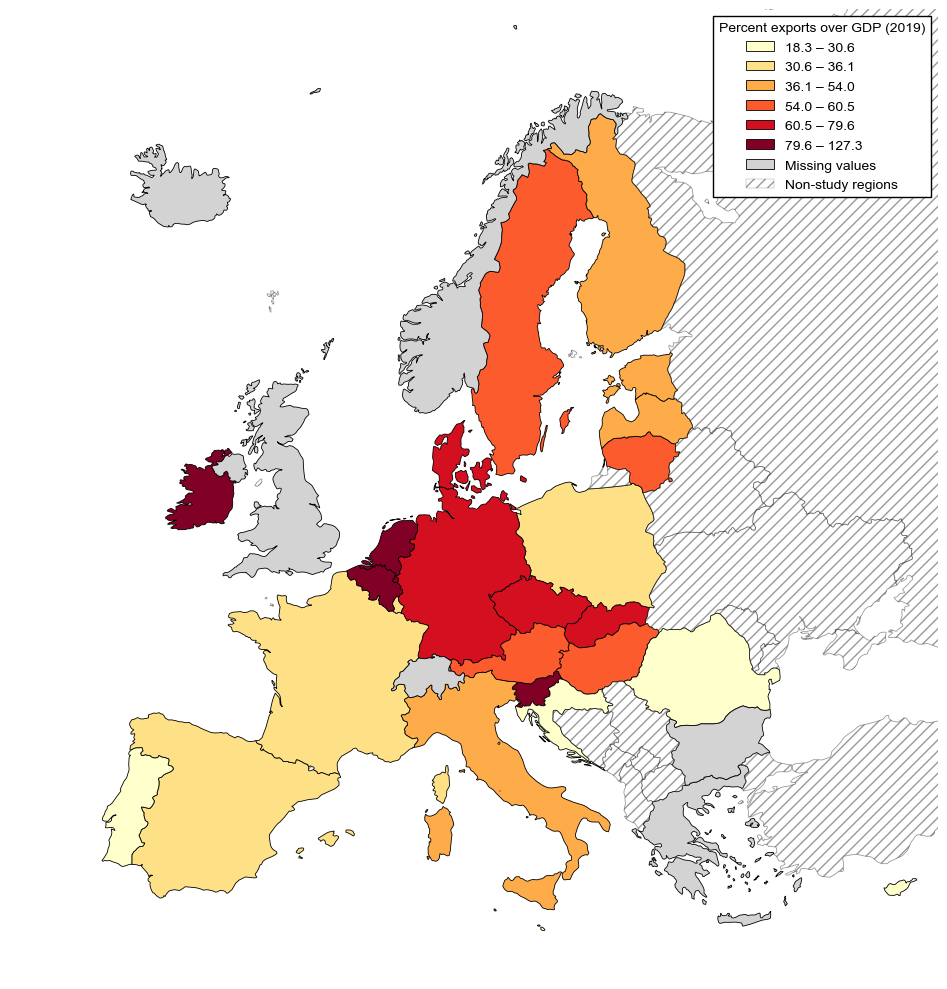

In [138]:
fig, ax = plot_functions.plot_europe_map(df=df[['geo', 'year', 'value_exports']].rename(columns={"value_exports": "value"}), year=2019, value_title='Percent exports over GDP', colormap='YlOrRd', k=6)

In [139]:
df.columns

Index(['geo', 'year', 'value_exports', 'value_imports', 'balance'], dtype='object')

In [140]:
df[['geo', 'year', 'value_exports']].reset_index().rename(columns={'value_y':'Final energy','value_x':'Population'}).to_excel(r'figure_13.xlsx')

In [141]:
df[['geo', 'year', 'value_exports']]

,geo,year,value_exports
0,AT,2002,52.247971
1,AT,2004,55.002201
2,AT,2009,49.934129
3,AT,2014,60.324412
4,AT,2019,60.516277
...,...,...,...
145,SK,2004,38.766199
146,SK,2009,50.657396
147,SK,2014,69.291692
148,SK,2019,79.640907
